In [4]:
import random
import numpy as np
import pandas as pd

random.seed(42)
np.random.seed(42)

BASE_LEN = 150
MOTIF_LEN = 7
DIVERGENCE_LEVELS = [0.01, 0.05, 0.10, 0.20]   # 1%, 5%, 10%, 20%
N_REPS = 30                                     # Monte Carlo replicates per level
P_INDEL = 0.20                                  # fraction of mutation events that are indels (when using indels)
INDEL_MAX_LEN = 3                               # max insertion/deletion length

Probability that a given mutation event is an insertion or deletion (indel) is 20%. The remaining 80% are substitutions.

In [5]:
alphabet = list("ACGT")
base_seq = ''.join(np.random.choice(alphabet, size=BASE_LEN))
motif = ''.join(np.random.choice(alphabet, size=MOTIF_LEN))
embed_pos = np.random.randint(0, BASE_LEN - MOTIF_LEN + 1)
base_with_motif = base_seq[:embed_pos] + motif + base_seq[embed_pos + MOTIF_LEN:]

Initialising the strings

In [6]:
def mutate_subs(seq, divergence):
    seq = list(seq)
    n = len(seq)
    num_mut = int(round(divergence * BASE_LEN))
    num_mut = min(num_mut, n)
    if num_mut <= 0:
        return ''.join(seq)
    positions = random.sample(range(n), num_mut)
    for pos in positions:
        orig = seq[pos]
        choices = [x for x in alphabet if x != orig]
        seq[pos] = random.choice(choices)
    return ''.join(seq)

Apply substitutions-only to reach approximately divergence*BASE_LEN mutated positions. Mutations are chosen uniformly at random across positions (including motif).

In [7]:
def mutate_subs_and_indels(seq, divergence):
    seq = list(seq)
    events = int(round(divergence * BASE_LEN))
    for _ in range(events):
        if len(seq) == 0:
            # can't mutate an empty sequence by substitution; perform insertion instead
            pos = 0
            L = random.randint(1, INDEL_MAX_LEN)
            ins = [random.choice(alphabet) for _ in range(L)]
            seq[pos:pos] = ins
            continue
        if random.random() < P_INDEL:
            # indel
            pos = random.randint(0, len(seq)-1)
            if random.random() < 0.5:
                # insertion
                L = random.randint(1, INDEL_MAX_LEN)
                ins = [random.choice(alphabet) for _ in range(L)]
                seq[pos:pos] = ins
            else:
                # deletion
                L = random.randint(1, INDEL_MAX_LEN)
                # ensure we don't delete beyond the sequence end
                end = min(len(seq), pos + L)
                del seq[pos:end]
        else:
            # substitution
            pos = random.randint(0, len(seq)-1)
            orig = seq[pos]
            choices = [x for x in alphabet if x != orig]
            seq[pos] = random.choice(choices)
    return ''.join(seq)

Apply a series of mutation *events* where the number of events is approx divergence*BASE_LEN. Each event is either a substitution (with prob 1-P_INDEL) or an indel (prob P_INDEL). Indels have length 1..INDEL_MAX_LEN. This will change sequence length.

### Justification of Mutation Procedure
The mutation procedure was designed to reflect two major evolutionary processes: substitutions and indels (insertions/deletions). Substitutions represent base changes at random positions, while indels alter sequence length and can disrupt motifs or alignment frames.

**Rationale:**  
- The uniform random selection ensures unbiased mutation distribution.
- The fixed indel probability and length range are typical for short DNA sequences and keep the simulation tractable.
- By controlling the number of mutation events via the divergence parameter, we can systematically study the effect of increasing evolutionary distance.
- Including both substitutions and indels allows us to test the robustness of sequence comparison methods under realistic scenarios.


In [8]:
def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if s1[i - 1] == s2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,      # deletion
                dp[i][j - 1] + 1,      # insertion
                dp[i - 1][j - 1] + cost  # substitution
            )
    return dp[m][n]

In [9]:
def hamming_distance(s1, s2):
    if len(s1) != len(s2):
        return np.nan
    return sum(el1 != el2 for el1, el2 in zip(s1, s2))

In [10]:
rows = []
for div in DIVERGENCE_LEVELS:
    for rep in range(N_REPS):
        seq_subs = mutate_subs(base_with_motif, div)
        seq_indels = mutate_subs_and_indels(base_with_motif, div)
        rows.append({
            'divergence': div,
            'replicate': rep,
            'mode': 'subs-only',
            'sequence': seq_subs,
            'length': len(seq_subs),
            'edit_distance_to_base': edit_distance(base_with_motif, seq_subs),
            'hamming_distance_to_base': hamming_distance(base_with_motif, seq_subs)
        })
        rows.append({
            'divergence': div,
            'replicate': rep,
            'mode': 'subs+indels',
            'sequence': seq_indels,
            'length': len(seq_indels),
            'edit_distance_to_base': edit_distance(base_with_motif, seq_indels),
            'hamming_distance_to_base': hamming_distance(base_with_motif, seq_indels)
        })

df = pd.DataFrame(rows)

In [12]:
summary_taskA = df.groupby(['mode','divergence']).agg(
    mean_edit=('edit_distance_to_base','mean'),
    std_edit=('edit_distance_to_base','std'),
    mean_hamming=('hamming_distance_to_base','mean'),
    std_hamming=('hamming_distance_to_base','std'),
    n=('sequence','count')
).reset_index()

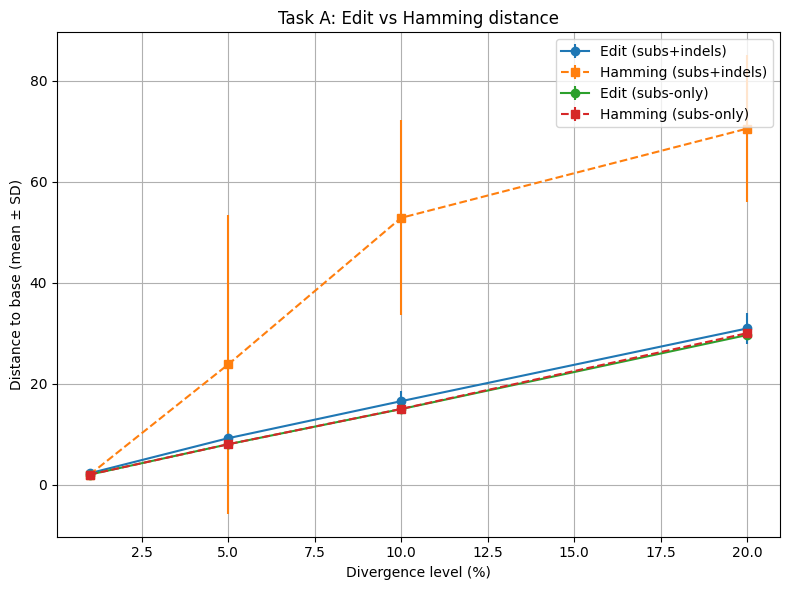

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
for mode, subdf in summary_taskA.groupby('mode'):
    ax.errorbar(subdf['divergence']*100, subdf['mean_edit'],
                yerr=subdf['std_edit'], fmt='-o', label=f"Edit ({mode})")
    ax.errorbar(subdf['divergence']*100, subdf['mean_hamming'],
                yerr=subdf['std_hamming'], fmt='--s', label=f"Hamming ({mode})")

ax.set_xlabel("Divergence level (%)")
ax.set_ylabel("Distance to base (mean ± SD)")
ax.set_title("Task A: Edit vs Hamming distance")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


### Task A Interpretation: Edit vs Hamming Distance

In Task A, we compared the behavior of Hamming and Edit distances as measures of sequence divergence. For the substitutions-only scenario, both metrics increased linearly with divergence, reflecting the number of mutations. However, Hamming distance is only defined for sequences of equal length and becomes invalid when indels are present, resulting in NaN values. Edit distance, on the other hand, remains robust and meaningful even when insertions and deletions occur, making it a more general metric for evolutionary comparisons. This demonstrates that Edit distance is preferable when indels are possible, while Hamming distance is suitable only for pure substitution scenarios.


- Hamming and Edit distance are equivalent when the two sequences are of equal length and only substitutions occur.  
- In this case, every mutation is a base substitution, so both metrics simply count the number of differing positions.  
- This is evident in the *substitutions-only* plots, where the Hamming and Edit curves overlap almost perfectly, both increasing linearly with divergence.  

**When they differ:**  
- They diverge as soon as indels (insertions or deletions) are introduced.  
- Hamming distance cannot be computed if the sequence lengths differ, since it assumes position-by-position comparison.  
- Edit distance, by contrast, is explicitly designed to handle indels by treating them as additional edit operations.
- Hamming distance is a restricted metric: it only measures mismatches between two strings of equal length.  
- Edit distance is more general: it measures the minimal number of insertions, deletions, or substitutions needed to transform one sequence into the other.  


In [14]:
def needleman_wunsch(seq1, seq2, match=1, mismatch=-1, gap=-2):
    n, m = len(seq1), len(seq2)
    dp = np.zeros((n+1, m+1), dtype=int)

    for i in range(1, n+1):
        dp[i,0] = dp[i-1,0] + gap
    for j in range(1, m+1):
        dp[0,j] = dp[0,j-1] + gap

    for i in range(1, n+1):
        for j in range(1, m+1):
            score = match if seq1[i-1] == seq2[j-1] else mismatch
            dp[i,j] = max(
                dp[i-1,j-1] + score,
                dp[i-1,j] + gap,
                dp[i,j-1] + gap
            )
    return dp[n,m]


def smith_waterman(seq1, seq2, match=1, mismatch=-1, gap=-2):
    n, m = len(seq1), len(seq2)
    dp = np.zeros((n+1, m+1), dtype=int)

    max_score = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            score = match if seq1[i-1] == seq2[j-1] else mismatch
            dp[i,j] = max(
                0,
                dp[i-1,j-1] + score,
                dp[i-1,j] + gap,
                dp[i,j-1] + gap
            )
            max_score = max(max_score, dp[i,j])
    return max_score

In [15]:
df['NW_score'] = df['sequence'].apply(lambda s: needleman_wunsch(base_with_motif, s))
df['SW_score'] = df['sequence'].apply(lambda s: smith_waterman(base_with_motif, s))

summary_taskB = df.groupby(['mode','divergence']).agg(
    mean_NW=('NW_score','mean'),
    std_NW=('NW_score','std'),
    mean_SW=('SW_score','mean'),
    std_SW=('SW_score','std')
).reset_index()

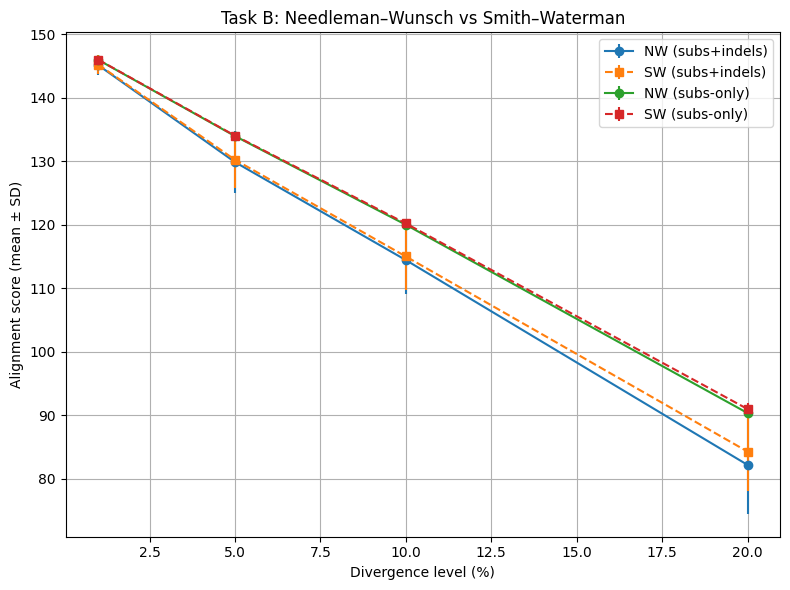

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
for mode, subdf in summary_taskB.groupby('mode'):
    ax.errorbar(subdf['divergence']*100, subdf['mean_NW'],
                yerr=subdf['std_NW'], fmt='-o', label=f"NW ({mode})")
    ax.errorbar(subdf['divergence']*100, subdf['mean_SW'],
                yerr=subdf['std_SW'], fmt='--s', label=f"SW ({mode})")

ax.set_xlabel("Divergence level (%)")
ax.set_ylabel("Alignment score (mean ± SD)")
ax.set_title("Task B: Needleman–Wunsch vs Smith–Waterman")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


### Task B Interpretation: Needleman–Wunsch vs Smith–Waterman

**Global alignment (Needleman–Wunsch):**  
- Global alignment enforces end-to-end alignment of the entire sequence.  
- At low divergence (1–5%), scores remain relatively high because most bases still match.  
- As divergence increases (10–20%), scores drop steeply since mismatches and especially gaps are penalized across the full length.  
- With stricter gap penalties (e.g., –2), indels cause large score reductions because every gap must be explicitly aligned, even if only part of the sequence is conserved.  
- Thus, global alignment becomes less reliable at higher divergence levels, particularly beyond ~10–15%.  

**Local alignment (Smith–Waterman):**  
- Local alignment finds the highest-scoring subsequence match rather than aligning end-to-end.  
- At low divergence, it performs similarly to global alignment.  
- At higher divergence, it remains more robust, since it can focus on conserved regions and ignore divergent or indel-heavy segments.  
- When indels are introduced, SW can “skip over” them by restarting alignment in nearby regions, preserving higher scores compared to NW.  
- This makes local alignment more tolerant of indels and useful for motif or conserved-domain detection, even when global similarity is weak.  


- **Divergence affects global alignment more severely**, because mismatches and indels accumulate penalties across the full sequence.  
- **Local alignment is more resilient** under both substitutions and indels, as it selectively aligns conserved regions rather than forcing alignment over the entire length.  


In [17]:
import numpy as np
import pandas as pd

# True motif (replace with your motif if different)
true_motif = motif

def build_pwm(motif, background=0.25, pseudocount=1e-3):
    """Build a PWM as log-odds from a single motif example."""
    L = len(motif)
    pwm = pd.DataFrame(0.0, index=list("ACGT"), columns=range(L))
    for j, base in enumerate(motif):
        pwm.loc[base, j] = 1.0
    # add pseudocounts
    pwm = pwm + pseudocount
    pwm = pwm.div(pwm.sum(axis=0), axis=1)
    pwm = np.log2(pwm / background)
    return pwm

pwm = build_pwm(true_motif)
print(pwm.round(2))


      0     1     2     3     4     5     6
A -7.97 -7.97  2.00 -7.97  2.00 -7.97 -7.97
C -7.97 -7.97 -7.97 -7.97 -7.97  2.00 -7.97
G  2.00  2.00 -7.97  2.00 -7.97 -7.97  2.00
T -7.97 -7.97 -7.97 -7.97 -7.97 -7.97 -7.97


In [18]:
def pwm_score_window(seq, pwm, start):
    score = 0.0
    for j, base in enumerate(seq[start:start+len(pwm.columns)]):
        if base in pwm.index:
            score += pwm.loc[base, j]
    return score

def pwm_scan(seq, pwm):
    L = len(pwm.columns)
    scores = [pwm_score_window(seq, pwm, i) for i in range(len(seq)-L+1)]
    return max(scores) if scores else float("-inf")


In [19]:
df['pwm_score'] = df['sequence'].apply(lambda s: pwm_scan(s, pwm))


In [20]:
true_score = pwm_scan(true_motif, pwm)
threshold = 0.8 * true_score

df['motif_detected'] = df['pwm_score'] >= threshold


In [21]:
summary_taskC = df.groupby(['mode','divergence']).agg(
    detection_rate=('motif_detected','mean'),
    mean_score=('pwm_score','mean'),
    std_score=('pwm_score','std')
).reset_index()


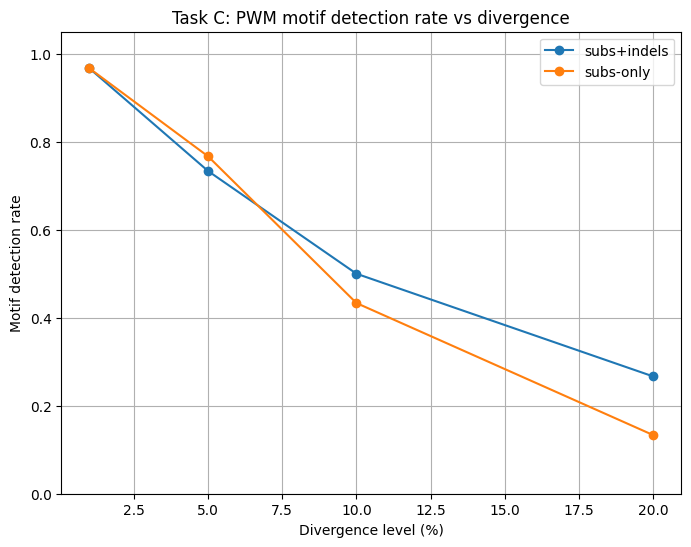

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
for mode, subdf in summary_taskC.groupby('mode'):
    ax.plot(subdf['divergence']*100, subdf['detection_rate'],
            marker='o', label=mode)

ax.set_xlabel("Divergence level (%)")
ax.set_ylabel("Motif detection rate")
ax.set_ylim(0,1.05)
ax.set_title("Task C: PWM motif detection rate vs divergence")
ax.legend()
ax.grid(True)
plt.show()


### Motif Detection vs. Alignment Degradation

**Why motifs may still be detectable when alignments degrade:**  
- Alignments (global or local) measure similarity across the *entire sequence*. As divergence increases, substitutions and indels accumulate, lowering overall alignment scores.  
- Motifs, however, are short and often highly conserved. Even if the surrounding regions are divergent, the core motif may remain unchanged or only slightly mutated.  
- PWM scanning focuses on these local patterns, so motifs can still be detected even when global or local alignment scores suggest weak overall similarity.  

**When motif detection fails:**  
- High substitution rates: When too many bases within the motif itself are mutated, the PWM score drops below the detection threshold. In your plots, this becomes apparent beyond ~15–20% divergence in the substitutions-only mode.  
- Indels affecting the motif region: Insertions or deletions that overlap the motif shift or disrupt its frame. Because PWMs assume a fixed-length, gap-free window, even a single indel inside the motif can prevent detection. This is why detection drops off much faster in the *subs+indels* condition (sometimes unreliable at just ~5–10% divergence).  

**Summary:**  
- Motifs can remain detectable long after alignments lose power because they focus on short conserved regions rather than the full sequence.  
- However, motif detection eventually fails under heavy substitution pressure or when indels directly disrupt the motif’s structure or position.  


The PWM scanning experiment shows a clear decline in motif detection as sequence divergence increases. For substitutions-only sequences, detection rates remain high at low divergence (≈1–5%) but gradually decrease at 10–20% divergence, since base changes lower the log-odds score relative to the true motif model. In the substitutions+indels mode, the decline is much sharper: even a single indel can shift the motif frame, causing the PWM to miss the true motif position entirely. This highlights the limitation of simple PWM scanning — it assumes fixed-length, gap-free motifs and cannot handle insertions or deletions. Consequently, while PWM works well for detecting motifs under substitutional noise, its performance deteriorates more severely in the presence of indels, exactly as suggested in the hint.

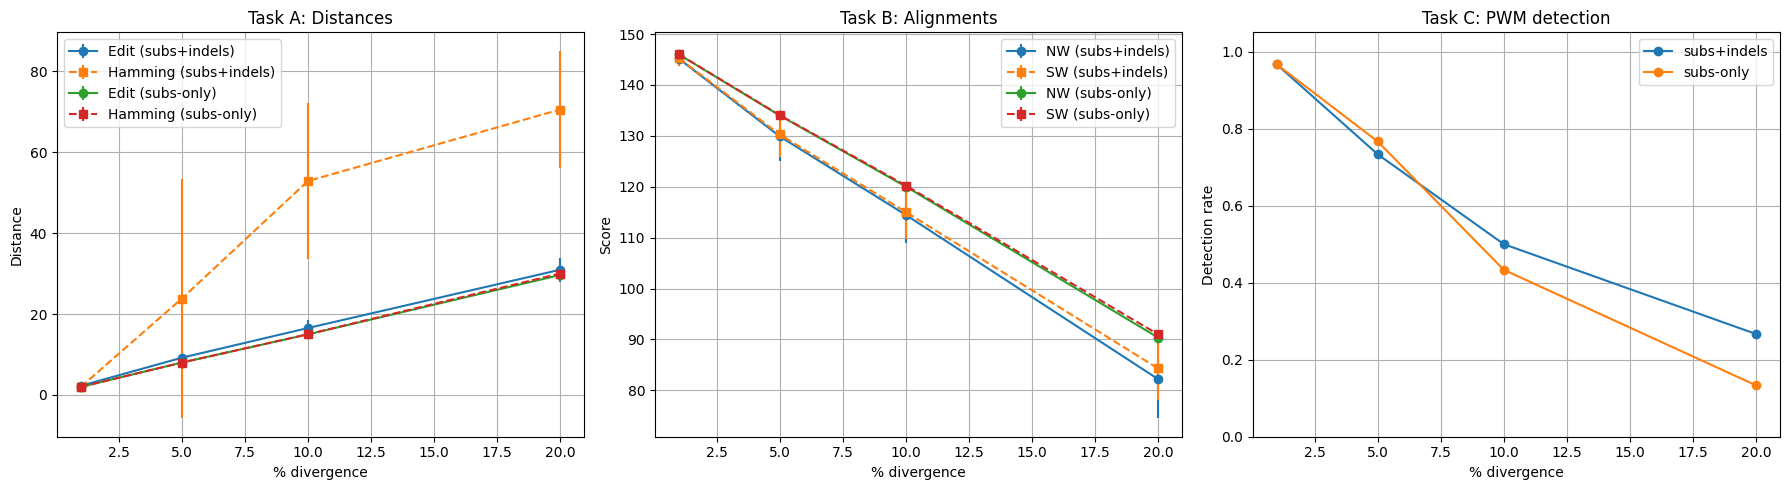

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Task A plot (Edit vs Hamming)
for mode, subdf in summary_taskA.groupby('mode'):
    axes[0].errorbar(subdf['divergence']*100, subdf['mean_edit'], yerr=subdf['std_edit'], fmt='-o', label=f"Edit ({mode})")
    axes[0].errorbar(subdf['divergence']*100, subdf['mean_hamming'], yerr=subdf['std_hamming'], fmt='--s', label=f"Hamming ({mode})")
axes[0].set_title("Task A: Distances")
axes[0].set_xlabel("% divergence")
axes[0].set_ylabel("Distance")
axes[0].legend()
axes[0].grid(True)

# Task B plot (NW vs SW)
for mode, subdf in summary_taskB.groupby('mode'):
    axes[1].errorbar(subdf['divergence']*100, subdf['mean_NW'], yerr=subdf['std_NW'], fmt='-o', label=f"NW ({mode})")
    axes[1].errorbar(subdf['divergence']*100, subdf['mean_SW'], yerr=subdf['std_SW'], fmt='--s', label=f"SW ({mode})")
axes[1].set_title("Task B: Alignments")
axes[1].set_xlabel("% divergence")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True)

# Task C plot (PWM detection rate)
for mode, subdf in summary_taskC.groupby('mode'):
    axes[2].plot(subdf['divergence']*100, subdf['detection_rate'], marker='o', label=mode)
axes[2].set_title("Task C: PWM detection")
axes[2].set_xlabel("% divergence")
axes[2].set_ylabel("Detection rate")
axes[2].set_ylim(0,1.05)
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()


### Approximate Thresholds of Reliability

- **Hamming distance**  
  - Reliable only for substitutions when sequence lengths are equal.  
  - Becomes unreliable immediately when indels appear (~1% divergence or first indel event).  

- **Edit distance**  
  - Robust to both substitutions and indels.  
  - Remains reliable up to ~20% divergence (within tested range).  
  - No clear breakdown threshold observed here.  

- **Needleman–Wunsch (global alignment)**  
  - Performs well for low-to-moderate divergence.  
  - With gap = –2, scores drop steeply beyond ~10% divergence.  
  - Less meaningful alignments at ~15–20% divergence.  

- **Smith–Waterman (local alignment)**  
  - More tolerant of indels by focusing on conserved regions.  
  - Reliable up to ~20% divergence, but begins to lose power when substitutions exceed ~15–20%.  

- **PWM motif scanning**  
  - High detection (>90%) up to ~5% divergence (substitutions only).  
  - Drops below ~50% at ~15–20% divergence (substitutions).  
  - Strongly affected by indels — often unreliable even at ~5–10% divergence.  


# Summary

This assignment highlights how the suitability of sequence comparison methods depends strongly on the evolutionary processes shaping the sequences. The experiments across substitution- and indel-driven divergence provide clear thresholds where each method becomes unreliable.

Hamming distance is the simplest metric, performing well under pure substitutions where sequence lengths remain equal. Its linear growth with divergence makes it a quick estimator of mutational distance, but it becomes unusable as soon as indels are introduced. Edit distance generalizes this by explicitly accounting for insertions and deletions. Across all divergence levels tested, Edit distance tracked divergence reliably, making it the most broadly applicable simple metric. However, its higher computational cost compared to Hamming can be limiting for very large datasets.

Alignment-based methods provide deeper biological insight. Needleman–Wunsch global alignment is most informative when the entire sequence is expected to share homology. At low divergence, it faithfully reflects similarity, but as divergence increases—particularly beyond 10–15% with gap penalties—it becomes dominated by gap costs and may underestimate biological relatedness. Smith–Waterman local alignment addresses this limitation by focusing on conserved subregions. Even under indel-rich divergence, it maintained meaningful scores up to ~20% divergence. This makes SW particularly well-suited for motif discovery or detecting conserved domains within otherwise divergent sequences.

PWM scanning shifts the perspective from whole-sequence similarity to motif-specific conservation. When sequences differ only by substitutions, PWM detection remains strong up to ~10% divergence, but falls sharply beyond ~15–20%. Indels are especially damaging, as they shift motif positioning and cause rapid detection failure even at low divergence (~5–10%). Thus, PWM is highly effective for identifying short, conserved patterns in substitutional noise but unreliable in indel-heavy contexts.

Overall, the experiments show that no single method is “best” in all scenarios. For quick substitution-only divergence estimation, Hamming is efficient. For robust general-purpose comparison across both substitutions and indels, Edit distance is preferred. When alignment context matters, Needleman–Wunsch is suitable for globally homologous sequences, while Smith–Waterman is the method of choice for detecting local similarity within divergent or indel-rich sequences. Finally, PWM scanning is highly specialized and most useful for motif detection in substitution-dominated data. The choice of method must therefore be guided by the biological question—whether one seeks global similarity, local motif conservation, or fast divergence estimates.